# Business Sales Performance Analytics

## Future Interns - Data Science & Analytics Internship

### Task 1: Business Sales Performance Analytics

'''This project analyzes business sales data to identify revenue trends,
top-selling products, high-value categories, regional performance,
and profitability patterns.'''

### Objectives
'''- Analyze overall sales and profitability
- Identify sales trends over time
- Identify top-performing products and categories
- Analyze regional performance
- Examine the relationship between discounts and profitability
- Generate actionable business insights and recommendations'''


# Business Sales Performance Analytics

## 1. Project Objective

This project analyzes business sales data to identify revenue trends,
top-selling products, high-value categories, regional performance,
and profitability patterns.



In [47]:
import pandas as pd
import numpy as np
import seaborn as sns

In [49]:
data=pd.read_csv(r"C:\Users\snehi\Downloads\Sample - Superstore.csv.zip",encoding="latin1")

## 2. Data Cleaning

The dataset was checked for missing values and duplicate records.
The Order Date and Ship Date columns were converted to datetime format.

In [50]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [51]:
data.shape

(9994, 21)

In [52]:
data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [53]:
data.duplicated().sum()

np.int64(0)

In [12]:
data.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [13]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

In [14]:
data.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

## 3. Overall Business KPIs

In [15]:
data[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


We calculate total sales, profit, quantity sold, number of orders,
and profit margin.

In [16]:
total_sales = data['Sales'].sum()
total_profit = data['Profit'].sum()
total_quantity = data['Quantity'].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity Sold:", total_quantity)

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Quantity Sold: 37873


In [17]:
total_orders = data['Order ID'].nunique()
average_order_value = total_sales / total_orders

print("Total Orders:", total_orders)
print("Average Order Value:", average_order_value)

Total Orders: 5009
Average Order Value: 458.6146656618087


In [18]:
profit_margin = (total_profit / total_sales) * 100

print("Profit Margin:", round(profit_margin, 2), "%")

Profit Margin: 12.47 %


In [20]:
data['Year'] = data['Order Date'].dt.year
data['Month'] = data['Order Date'].dt.month
data['Year-Month'] = data['Order Date'].dt.to_period('M').astype(str)

In [21]:
data[['Order Date', 'Year', 'Month', 'Year-Month']].head()

,Order Date,Year,Month,Year-Month
0,2016-11-08,2016,11,2016-11
1,2016-11-08,2016,11,2016-11
2,2016-06-12,2016,6,2016-06
3,2015-10-11,2015,10,2015-10
4,2015-10-11,2015,10,2015-10


## 4. Sales Trend Analysis


This section examines how sales changed over time.

In [22]:
yearly_sales = data.groupby('Year')['Sales'].sum()

print(yearly_sales)

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


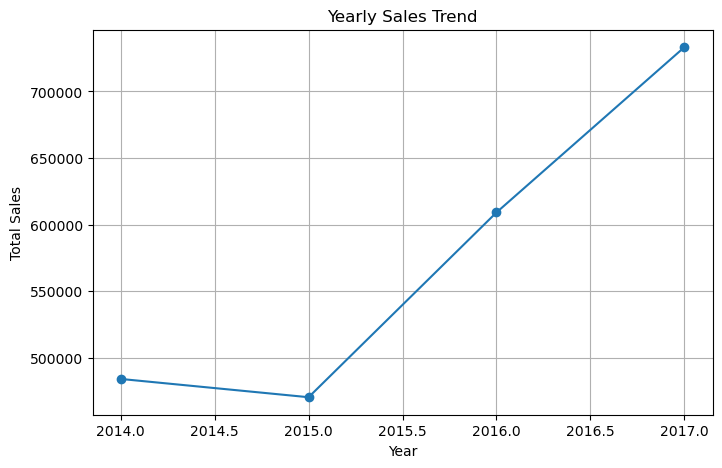

In [23]:
import matplotlib.pyplot as plt

yearly_sales.plot(kind='line', marker='o', figsize=(8,5))

plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

In [24]:
print(yearly_sales)

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


In [25]:
monthly_sales = data.groupby('Year-Month')['Sales'].sum()

print(monthly_sales)

Year-Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160


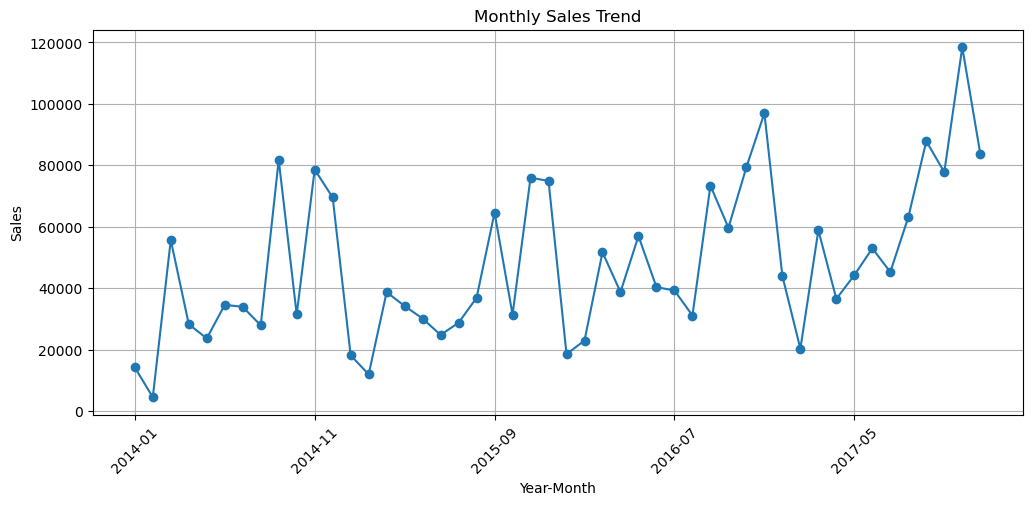

In [26]:
plt.figure(figsize=(12,5))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Year-Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## 5. Category & Sub-Category Analysis

In [27]:
category_sales = data.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [28]:
subcategory_sales = data.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

print(subcategory_sales)

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64


## 6. Top Products

In [29]:
top_products = (
    data.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


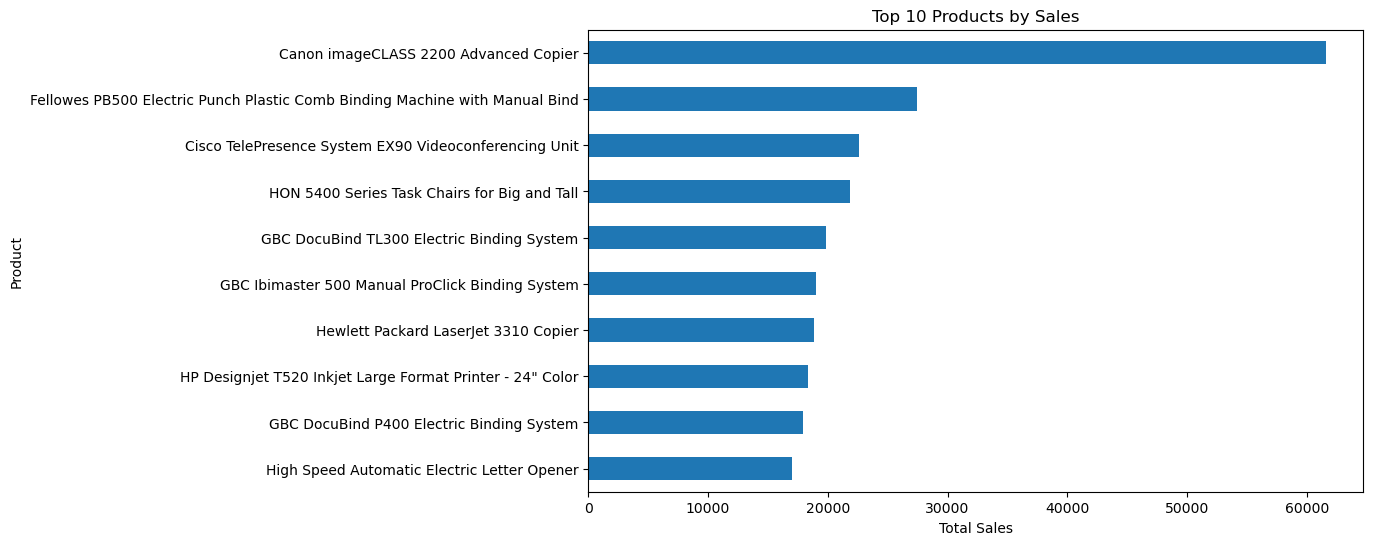

In [30]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.show()

## 7. Regional Performance

In [31]:
region_sales = data.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print(region_sales)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


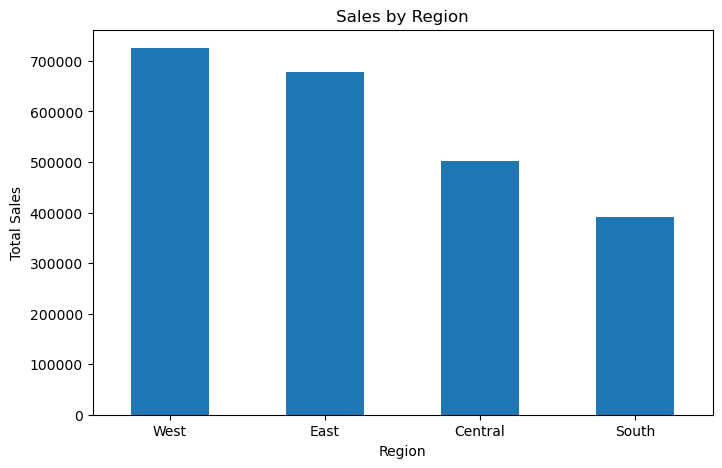

In [32]:
plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

In [33]:
region_performance = data.groupby('Region')[['Sales', 'Profit']].sum()

print(region_performance)

               Sales       Profit
Region                           
Central  501239.8908   39706.3625
East     678781.2400   91522.7800
South    391721.9050   46749.4303
West     725457.8245  108418.4489


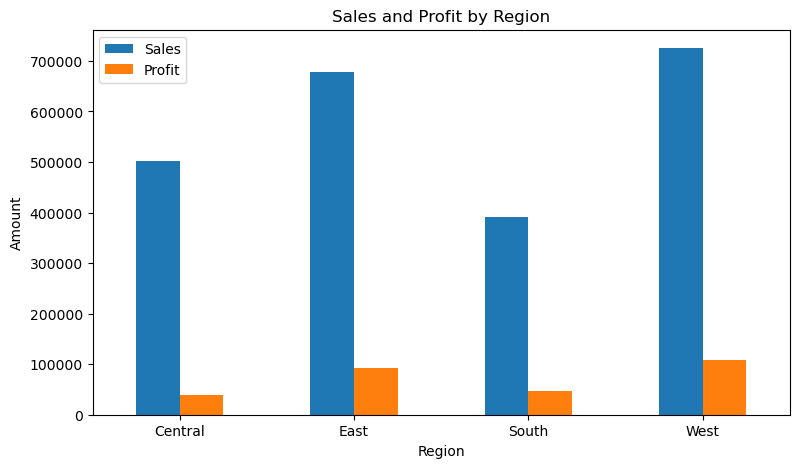

In [34]:
region_performance.plot(
    kind='bar',
    figsize=(9,5)
)

plt.title('Sales and Profit by Region')
plt.xlabel('Region')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.legend()
plt.show()

## 8. Discount & Profitability Analysis

In [35]:
discount_profit = data.groupby('Discount')['Profit'].sum()

print(discount_profit)

Discount
0.00    320987.6032
0.10      9029.1770
0.15      1418.9915
0.20     90337.3060
0.30    -10369.2774
0.32     -2391.1377
0.40    -23057.0504
0.45     -2493.1111
0.50    -20506.4281
0.60     -5944.6552
0.70    -40075.3569
0.80    -30539.0392
Name: Profit, dtype: float64


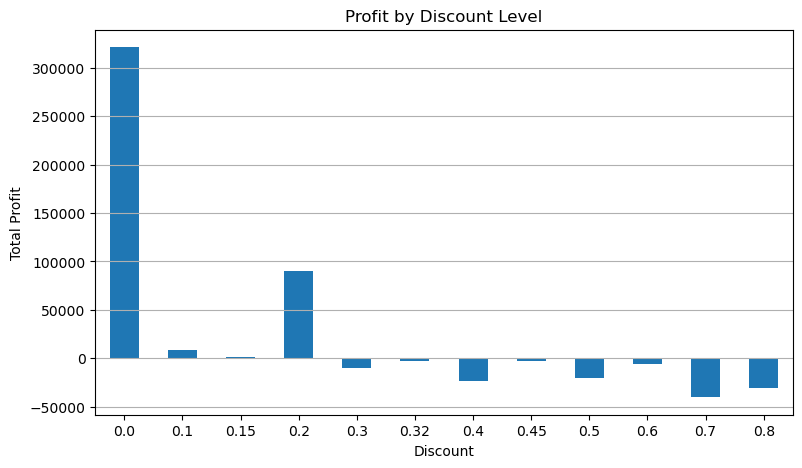

In [36]:
plt.figure(figsize=(9,5))

discount_profit.plot(kind='bar')

plt.title('Profit by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

In [37]:
discount_analysis = data.groupby('Discount').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Number_of_Orders=('Order ID', 'nunique')
)

discount_analysis['Profit_Margin'] = (
    discount_analysis['Total_Profit'] /
    discount_analysis['Total_Sales']
) * 100

print(discount_analysis.round(2))

          Total_Sales  Total_Profit  Number_of_Orders  Profit_Margin
Discount                                                            
0.00       1087908.47     320987.60              2644          29.51
0.10         54369.35       9029.18                89          16.61
0.15         27558.52       1418.99                51           5.15
0.20        764594.37      90337.31              2407          11.82
0.30        103226.66     -10369.28               211         -10.05
0.32         14493.46      -2391.14                27         -16.50
0.40        116417.78     -23057.05               185         -19.81
0.45          5484.97      -2493.11                10         -45.45
0.50         58918.54     -20506.43                64         -34.80
0.60          6644.70      -5944.66               127         -89.46
0.70         40620.28     -40075.36               344         -98.66
0.80         16963.76     -30539.04               250        -180.03


## 9. Key Findings & Recommendations

# final insights

In [38]:
product_performance = data.groupby('Product Name').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
)

product_performance['Profit_Margin'] = (
    product_performance['Profit'] /
    product_performance['Sales']
) * 100

print(product_performance.sort_values('Profit', ascending=True).head(10))

                                                        Sales     Profit  \
Product Name                                                               
Cubify CubeX 3D Printer Double Head Print           11099.963 -8879.9704   
Lexmark MX611dhe Monochrome Laser Printer           16829.901 -4589.9730   
Cubify CubeX 3D Printer Triple Head Print            7999.980 -3839.9904   
Chromcraft Bull-Nose Wood Oval Conference Table...   9917.640 -2876.1156   
Bush Advantage Collection Racetrack Conference ...   9544.725 -1934.3976   
GBC DocuBind P400 Electric Binding System           17965.068 -1878.1662   
Cisco TelePresence System EX90 Videoconferencin...  22638.480 -1811.0784   
Martin Yale Chadless Opener Electric Letter Opener  16656.200 -1299.1836   
Balt Solid Wood Round Tables                         6518.754 -1201.0581   
BoxOffice By Design Rectangular and Half-Moon M...   1706.250 -1148.4375   

                                                    Profit_Margin  
Product Name       

In [39]:
category_performance = data.groupby('Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
)

category_performance['Profit_Margin'] = (
    category_performance['Profit'] /
    category_performance['Sales']
) * 100

print(category_performance.round(2))

                     Sales     Profit  Profit_Margin
Category                                            
Furniture        741999.80   18451.27           2.49
Office Supplies  719047.03  122490.80          17.04
Technology       836154.03  145454.95          17.40


## 9. Key Findings

### Overall Performance
- Total sales were approximately 2.30 million.
- Total profit was approximately 286.40 thousand.
- Overall profit margin was approximately 12.47%.
- A total of 37,873 units were sold.

### Sales Trends
- Sales decreased slightly from 2014 to 2015.
- Sales increased substantially in 2016 and reached the highest level in 2017.
- Monthly sales showed considerable variation throughout the period.

### Category Performance
- Technology generated the highest sales among the three categories.
- Technology and Office Supplies had profit margins of approximately 17%.
- Furniture generated substantial sales but had a much lower profit margin of approximately 2.49%.

### Regional Performance
- The West region generated the highest sales and profit.
- The East region was the second-highest in both sales and profit.
- Central generated more sales than South but had a lower total profit.
- South had the lowest sales among the four regions.

### Discount & Profitability
- Higher discount levels were associated with lower profit margins in the dataset.
- Discount levels of 30% or higher resulted in negative aggregated profit margins.

### Product Performance
- Phones and Chairs were the highest-selling sub-categories.
- Several products generated sales while recording negative profits, indicating areas that may require further profitability analysis.

## 10. Business Recommendations

1. **Review high-discount transactions**
   - Analyze high-discount orders to understand their effect on profitability.
   - Review whether large discounts are financially sustainable.

2. **Investigate Furniture profitability**
   - Furniture generated substantial sales but had only a 2.49% profit margin.
   - Review product pricing, costs, and discount patterns within this category.

3. **Investigate loss-making products**
   - Identify products with negative profit and examine their pricing, discounts, and costs.

4. **Monitor regional profitability**
   - Compare sales and profit together rather than relying only on sales.
   - Investigate regions where relatively high sales are accompanied by lower profitability.

5. **Monitor high-performing products**
   - Track major revenue-generating products and evaluate their profitability to ensure high sales translate into sustainable profit.

## 11. Conclusion

The analysis provides an overview of sales trends, product and category
performance, regional performance, and profitability patterns.

The findings show that sales volume does not always correspond to
profitability. In particular, Furniture and several high-discount or
loss-making products require further investigation.

These insights can support data-driven decisions related to pricing,
discount management, product performance, and regional sales strategy.